<center>
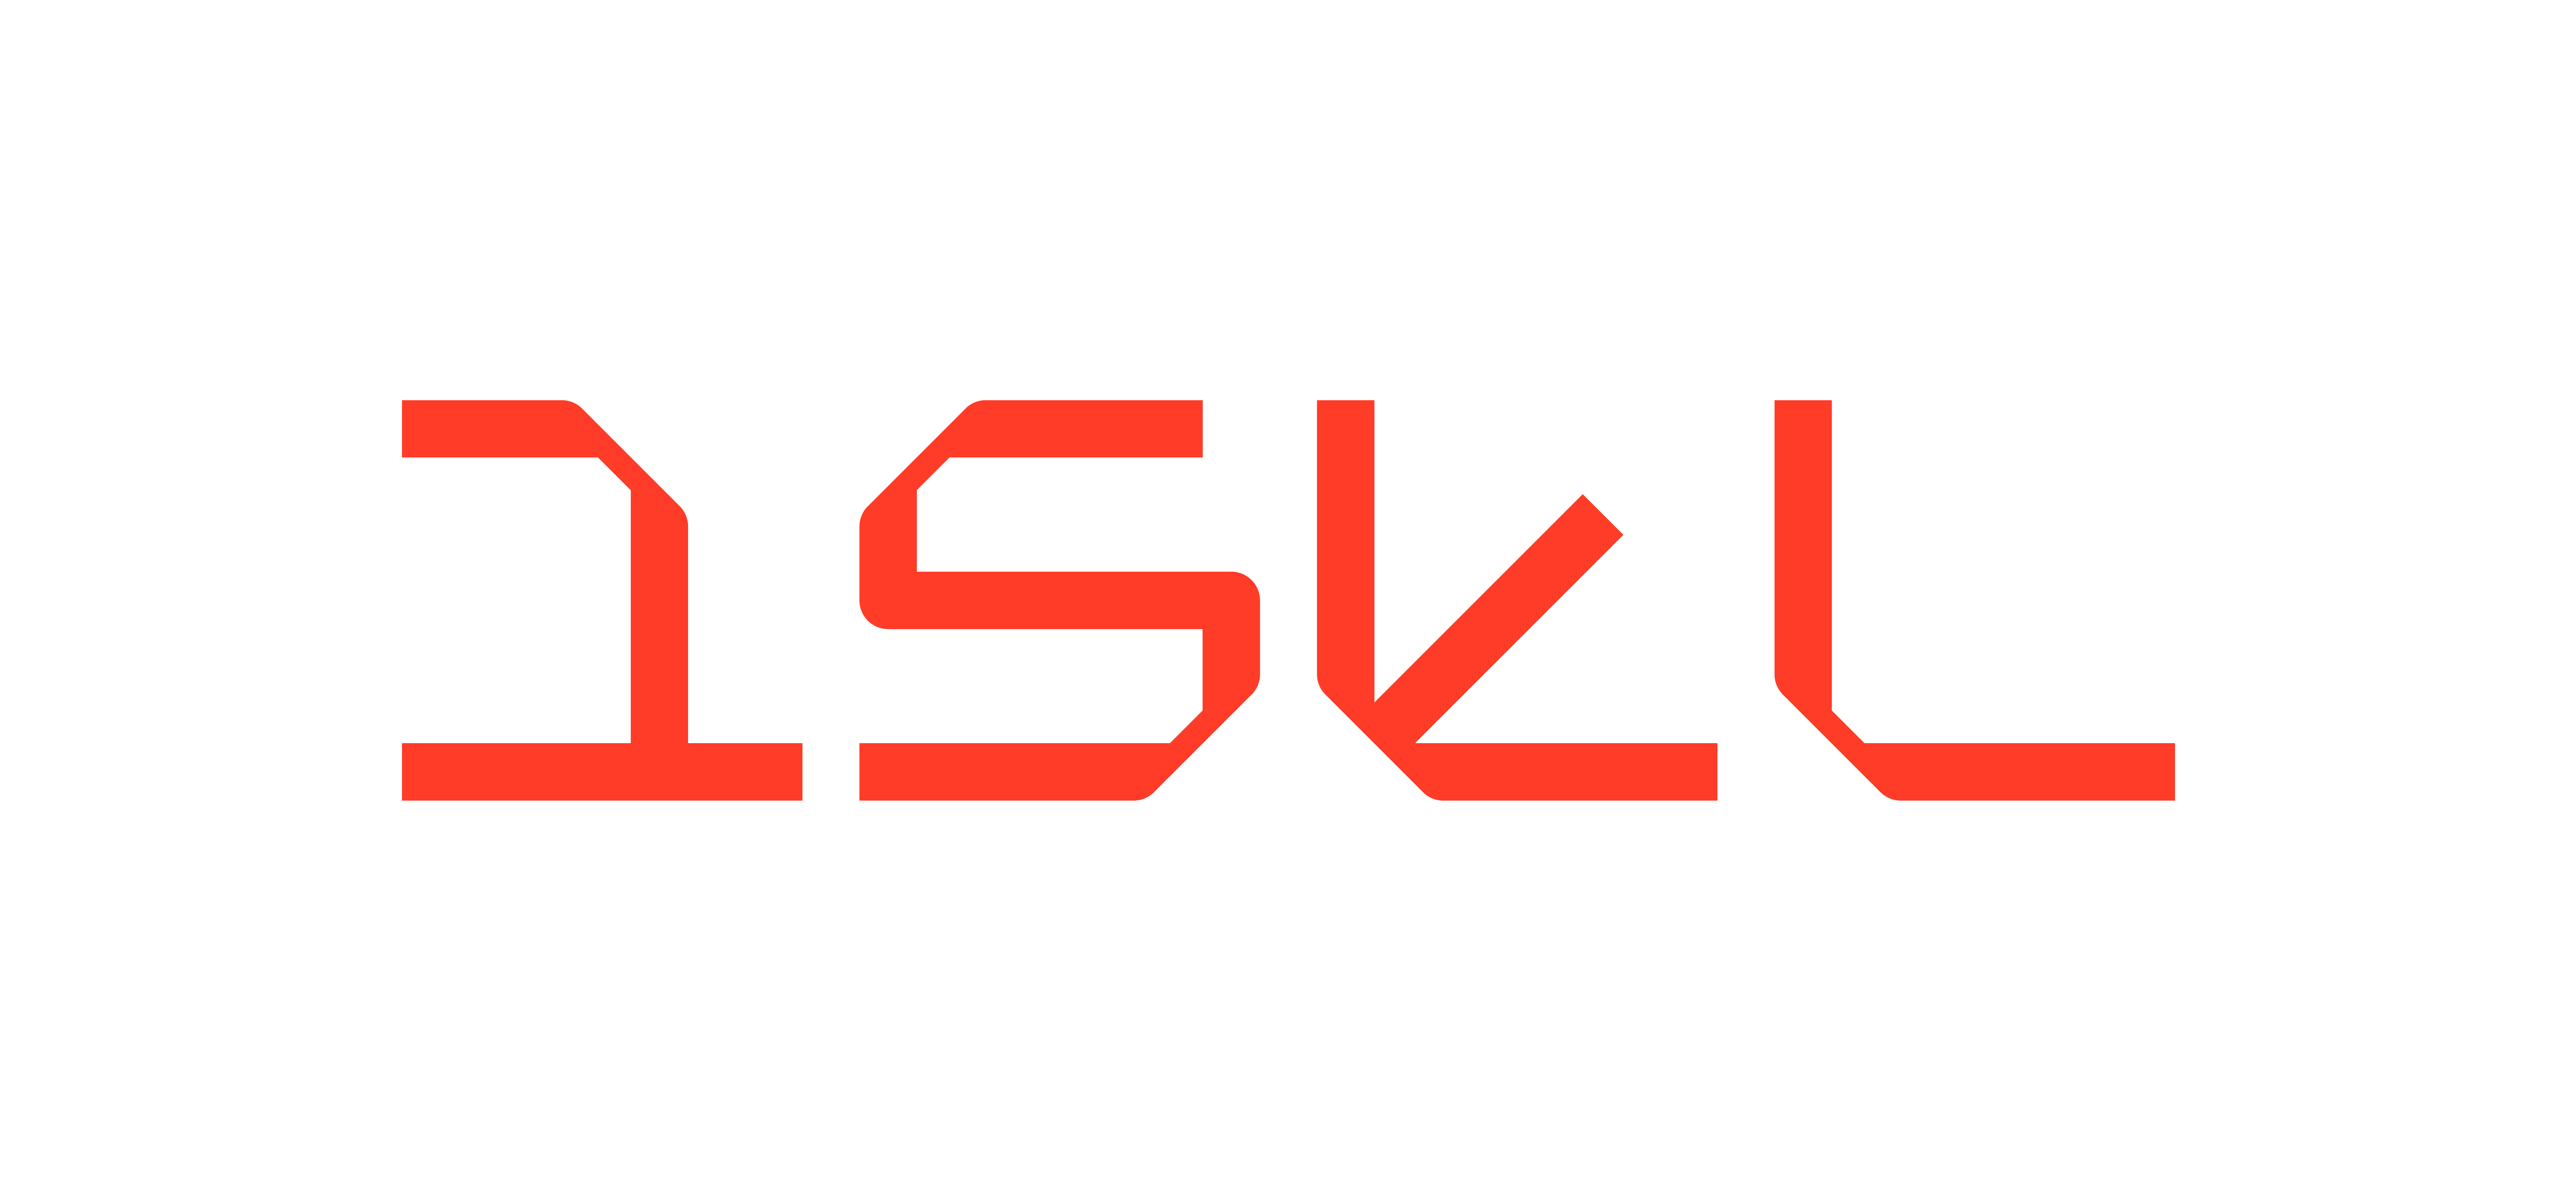
</center>

## <center><b>Instituto Superior de Engenharia de Lisboa<b></center>
### <center>Licenciatura em Engenharia Informática e Multimédia</center>
### <center><b>Processamento de Imagem e Visão</b><br>1º Semestre de 2025/2026</center>
#### <center><b>Trabalho Práctico 2</b></center>

<a id="inicio"></a>

<hr>
<br>
<center>Trabalho realizado por:<br>
• 46346 Inês Silva<br>
• 50274 Joana Araújo </center>
<br>

<br>

<center><b>Turma 51N ▪ Docente Nuno Silva</b></center><br>
<hr>

### <center>**Introdução**</center> <a class="anchor" id="chapter1"></a>

In [1]:
# importação das bibliotecas

import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
from collections import Counter
import time

In [13]:
folder = "assets/media/"
frame_test = cv.imread(folder + "img_teste_4.png")

Frame capturado: (480, 640, 3)


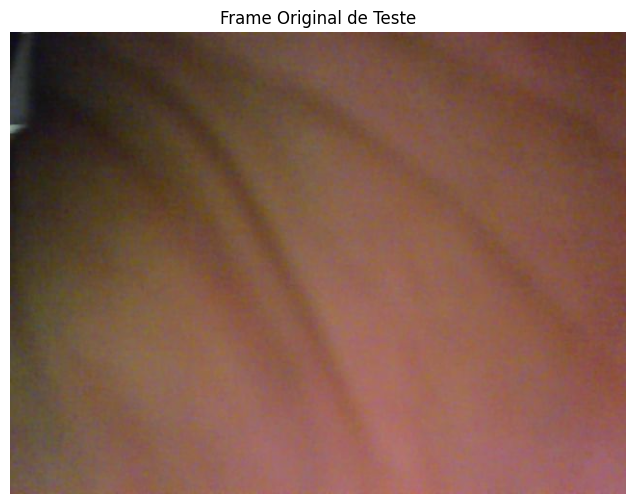

In [2]:
# Capturar um frame da webcam para experiência

cap = cv.VideoCapture(0)
ret, frame_test = cap.read()
cap.release()

if ret:
    # Espelha o frame para ser mais intuitivo
    frame_test = cv.flip(frame_test, 1)  
    print(f"Frame capturado: {frame_test.shape}")
    
    plt.figure(figsize=(10, 6))
    plt.imshow(cv.cvtColor(frame_test, cv.COLOR_BGR2RGB))
    plt.title("Frame Original de Teste")
    plt.axis('off')
    plt.show()
else:
    print("Erro ao capturar frame da webcam")

In [3]:
frame_test.shape[1]

640

In [4]:
def get_hsv_bounds(color_hsv, tolerance):
    """Calcula limites min/max seguros para HSV com tolerância."""
    # Usar np.clip para garantir que não sai de 0-179 ou 0-255
    # Converter para int32 para evitar overflow durante a soma/subtração
    h, s, v = color_hsv.astype(np.int32)
    
    h_min = np.clip(h - tolerance, 0, 179)
    h_max = np.clip(h + tolerance, 0, 179)
    s_min = np.clip(s - tolerance*2, 0, 255) # Saturação permite mais margem
    s_max = np.clip(s + tolerance*2, 0, 255)
    v_min = np.clip(v - tolerance*2, 0, 255)
    v_max = np.clip(v + tolerance*2, 0, 255)

    return np.array([h_min, s_min, v_min], dtype=np.uint8), \
           np.array([h_max, s_max, v_max], dtype=np.uint8)

In [5]:
def show_grid(images, titles, main_title="Análise", rows=1, cols=3):
    """Função genérica para exibir múltiplas imagens lado a lado."""
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
    axes = np.array(axes).flatten() # Garante que podemos iterar mesmo se for 1 linha
    
    for ax, img, title in zip(axes, images, titles):
        if len(img.shape) == 3:
            # Converter BGR para RGB para o Matplotlib
            ax.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        else:
            # Imagem grayscale/binária
            ax.imshow(img, cmap='gray')
        ax.set_title(title)
        ax.axis('off')
    
    plt.suptitle(main_title, fontsize=16)
    plt.tight_layout()
    plt.show()

In [6]:
def get_dominant_background_color(frame):
    """
    Identifica a cor de fundo analisando as bordas da imagem.
    """
    h, w = frame.shape[:2]
    
    # Definir Regiões de Interesse (ROIs) apenas nas bordas
    # (Top, Bottom, Left, Right strips)
    regions = [
        frame[0:h//4, :],      # Topo
        frame[3*h//4:h, :],    # Fundo
        frame[:, 0:w//4],      # Esquerda
        frame[:, 3*w//4:w]     # Direita
    ]
    
    region_means = []
    for region in regions:
        # Média das cores em cada faixa
        mean_color = np.mean(region, axis=(0, 1))
        region_means.append(mean_color)
    
    # A mediana das médias das bordas é robusta contra ruído/objetos numa das bordas
    dominant_bg = np.median(region_means, axis=0).astype(np.uint8)
    
    return dominant_bg

In [7]:
def analyze_colors_dashboard(frame):
    """
    Gera a visualização (Histogramas e Cor Dominante).
    """
    bg_color = get_dominant_background_color(frame)
    hsv = cv.cvtColor(frame, cv.COLOR_BGR2HSV)
    
    # Calcular histogramas
    hist_labels = ('Hue', 'Sat', 'Val')
    colors = ('r', 'g', 'b')
    hists = []
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    
    # 1. Frame Original
    axes[0,0].imshow(cv.cvtColor(frame, cv.COLOR_BGR2RGB))
    axes[0,0].set_title(f"Original (Fundo: {bg_color})")
    
    # 2. Cor Sólida Detectada
    bg_patch = np.zeros((100, 100, 3), dtype=np.uint8) + bg_color
    axes[0,1].imshow(cv.cvtColor(bg_patch, cv.COLOR_BGR2RGB))
    axes[0,1].set_title("Cor de Fundo Estimada")
    
    # 3. Histogramas (H, S, V)
    ax_hist = axes[1,0]
    for i, (col, label) in enumerate(zip(colors, hist_labels)):
        limit = 180 if i==0 else 256
        hist = cv.calcHist([hsv], [i], None, [limit], [0, limit])
        ax_hist.plot(hist, color=col, label=label)
    ax_hist.legend()
    ax_hist.set_title("Histogramas HSV")
    
    axes[1,1].axis('off') # Slot vazio ou para outra info
    plt.tight_layout()
    plt.show()

In [8]:
def segment_background_hsv(frame, bg_color, tolerance=30, debug=False):
    """Segmentação por subtração de cor de fundo (HSV)."""
    
    # 1. Preparação
    frame_hsv = cv.cvtColor(frame, cv.COLOR_BGR2HSV)
    bg_hsv = cv.cvtColor(np.uint8([[bg_color]]), cv.COLOR_BGR2HSV)[0][0]
    
    # 2. Obter limites (usando a função auxiliar)
    lower, upper = get_hsv_bounds(bg_hsv, tolerance)
    
    # 3. Criar Máscara
    mask_bg = cv.inRange(frame_hsv, lower, upper)
    mask_inv = cv.bitwise_not(mask_bg) # Inverter para obter o objeto
    
    # 4. Limpeza Morfológica
    kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (3,3))
    mask_clean = cv.morphologyEx(mask_inv, cv.MORPH_OPEN, kernel, iterations=2)
    mask_clean = cv.morphologyEx(mask_clean, cv.MORPH_CLOSE, kernel, iterations=2)
    
    if debug:
        show_grid([frame, mask_bg, mask_clean], 
                  ["Original", "Máscara Fundo", "Máscara Final"],
                  main_title="Segmentação por Fundo HSV")
        
    return mask_clean

In [9]:
def segment_skin_ycrcb(frame, debug=False):
    """Segmentação por deteção de tons de pele (YCrCb + HSV)."""
    
    # 1. YCrCb (Luminância, Crominância Vermelha, Crominância Azul)
    ycrcb = cv.cvtColor(frame, cv.COLOR_BGR2YCrCb)
    lower_skin = np.array([0, 133, 77], dtype=np.uint8)
    upper_skin = np.array([255, 173, 127], dtype=np.uint8)
    mask_skin = cv.inRange(ycrcb, lower_skin, upper_skin)
    
    # 2. Limpeza Morfológica e Dilatação
    # Usamos kernels maiores aqui para unir partes do corpo
    kernel_clean = cv.getStructuringElement(cv.MORPH_ELLIPSE, (5,5))
    kernel_dilate = cv.getStructuringElement(cv.MORPH_ELLIPSE, (15,15))
    
    mask_clean = cv.morphologyEx(mask_skin, cv.MORPH_OPEN, kernel_clean, iterations=2)
    mask_final = cv.dilate(mask_clean, kernel_dilate, iterations=2)
    
    if debug:
        show_grid([frame, mask_skin, mask_final], 
                  ["Original", "Pele (YCrCb)", "Dilatada (Corpo)"],
                  main_title="Segmentação por Pele")
                  
    return mask_final

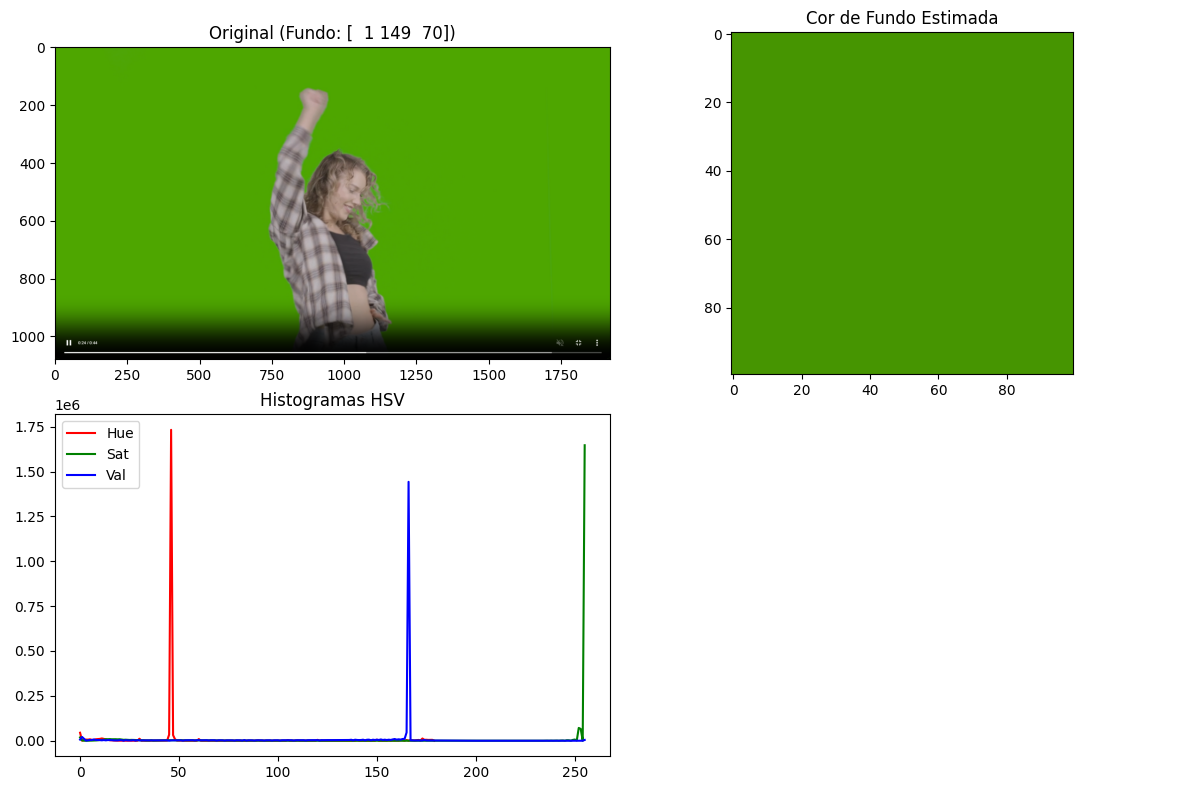

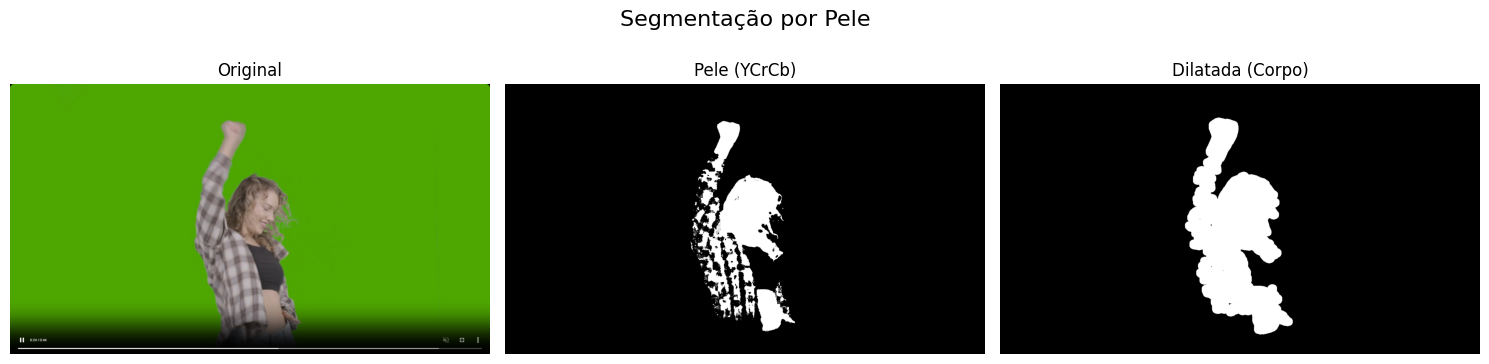

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(1080, 1920), dtype=uint8)

In [14]:
analyze_colors_dashboard(frame_test)
segment_skin_ycrcb(frame_test, True)

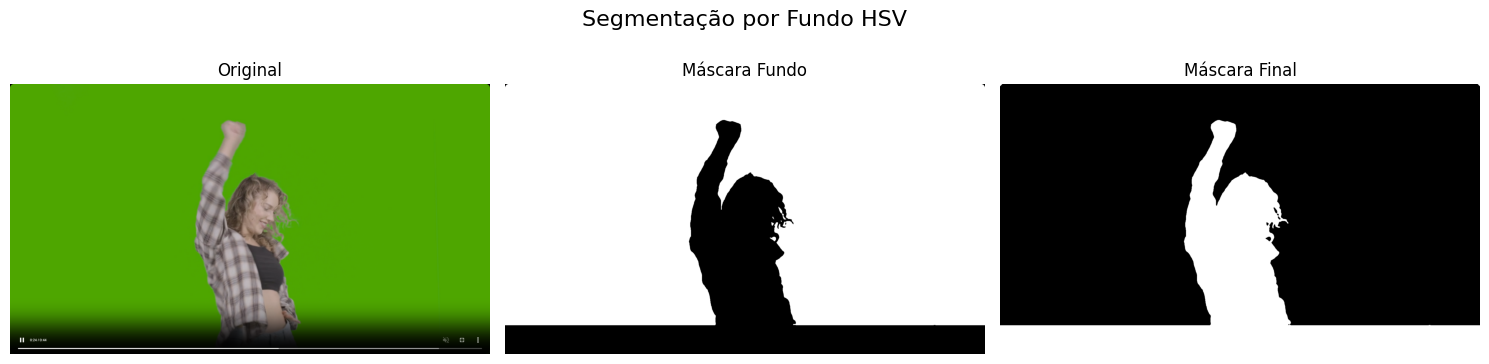

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]],
      shape=(1080, 1920), dtype=uint8)

In [19]:
bg_color = get_dominant_background_color(frame_test)
mask_person = segment_background_hsv(frame_test, bg_color, tolerance=30, debug=True)
mask_person

In [16]:
def get_contour_data(mask, min_area=1000):
    """
    Retorna uma lista de dicionários com dados de todos os contornos válidos.
    """
    contours, _ = cv.findContours(mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
    valid_data = []
    
    for cnt in contours:
        area = cv.contourArea(cnt)
        if area < min_area:
            continue
            
        M = cv.moments(cnt)
        if M["m00"] == 0: continue
        
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
        x, y, w, h = cv.boundingRect(cnt)
        
        valid_data.append({
            'contour': cnt,
            'area': area,
            'center': (cx, cy),
            'bbox': (x, y, w, h),
            'aspect_ratio': w / float(h) if h > 0 else 0
        })
        
    return valid_data

In [17]:
def detect_regions_by_position(mask, min_area=1000):
    """
    Classifica regiões baseando-se na altura Y (Topo/Meio/Baixo).
    """
    h, w = mask.shape[:2]
    objects = get_contour_data(mask, min_area)
    
    results = {'head': None, 'hands': [], 'feet': []}
    
    for obj in objects:
        rel_y = obj['center'][1] / h
        
        # Lógica de Posição
        if rel_y < 0.30:  # Topo (0-30%)
            # Se for muito grande, é a cabeça, senão é mão levantada
            if obj['area'] > min_area * 4:
                results['head'] = obj
            else:
                results['hands'].append(obj)
                
        elif rel_y < 0.70: # Meio (30-70%)
            results['hands'].append(obj)
            
        else: # Baixo (70-100%)
            results['feet'].append(obj)
            
    return results

def detect_extremities(mask):
    """
    Encontra os 4 pontos extremos e defeitos de convexidade do maior contorno.
    """
    contours, _ = cv.findContours(mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
    if not contours: return None
    
    # Focar apenas no maior contorno (o corpo principal)
    main_cnt = max(contours, key=cv.contourArea)
    
    # Extremos (Esquerda, Direita, Topo, Baixo)
    ext = {
        'left': tuple(main_cnt[main_cnt[:, :, 0].argmin()][0]),
        'right': tuple(main_cnt[main_cnt[:, :, 0].argmax()][0]),
        'top': tuple(main_cnt[main_cnt[:, :, 1].argmin()][0]),
        'bottom': tuple(main_cnt[main_cnt[:, :, 1].argmax()][0])
    }
    
    # Convex Hull e Defeitos (para contar dedos ou ver cavas)
    hull_indices = cv.convexHull(main_cnt, returnPoints=False)
    defects = None
    if len(hull_indices) > 3:
        try: defects = cv.convexityDefects(main_cnt, hull_indices)
        except: pass
        
    return {
        'contour': main_cnt,
        'extremes': ext,
        'defects': defects
    }

def detect_hybrid(mask):
    """
    Combina a análise de posição com as extremidades.
    """
    # 1. Obter regiões (Cabeça/Pés)
    pos_data = detect_regions_by_position(mask)
    
    # 2. Obter extremidades (Pontas dos dedos)
    ext_data = detect_extremities(mask)
    
    # 3. Refinar: As extremidades laterais (Esq/Dir) são quase sempre mãos
    # se não estiverem na zona dos pés.
    refined_hands = pos_data['hands'].copy() # Começa com as mãos detetadas por posição
    
    interest_points = [] # Pontos específicos (ex: ponta do dedo)
    
    if ext_data:
        h = mask.shape[0]
        extremes = ext_data['extremes']
        
        for name in ['left', 'right']:
            pt = extremes[name]
            # Se o ponto extremo não estiver muito em baixo (pés), é uma mão esticada
            if pt[1] < h * 0.80:
                interest_points.append({'point': pt, 'label': f'Hand Tip ({name})'})

    return {
        'head': pos_data['head'],
        'feet': pos_data['feet'],
        'hands_blobs': refined_hands,   # Mãos detectadas como "manchas"
        'hands_tips': interest_points,  # Pontas dos dedos detectadas por extremos
        'full_contour': ext_data['contour'] if ext_data else None
    }

In [21]:
def visualize_hybrid_results(frame, mask, results):
    """
    Gera gráficos para visualizar o resultado híbrido no Notebook.
    """
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # 1. Imagem Original + Máscara
    vis1 = cv.cvtColor(mask, cv.COLOR_GRAY2BGR)
    axes[0].imshow(vis1)
    axes[0].set_title("Máscara Binária")
    axes[0].axis('off')
    
    # 2. Detecção por Posição (Blobs)
    vis2 = frame.copy()
    
    # Cabeça
    if results['head']:
        x,y,w,h = results['head']['bbox']
        cv.rectangle(vis2, (x,y), (x+w, y+h), (255, 0, 255), 2)
        cv.putText(vis2, "HEAD", (x, y-10), cv.FONT_HERSHEY_SIMPLEX, 0.6, (255,0,255), 2)
        
    # Pés
    for foot in results['feet']:
        x,y,w,h = foot['bbox']
        cv.rectangle(vis2, (x,y), (x+w, y+h), (255, 0, 0), 2)
        cv.putText(vis2, "FOOT", (x, y-10), cv.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 2)
        
    axes[1].imshow(cv.cvtColor(vis2, cv.COLOR_BGR2RGB))
    axes[1].set_title("Regiões (Posição)")
    axes[1].axis('off')
    
    # 3. Detecção Híbrida (Pontos de Interesse)
    vis3 = frame.copy()
    
    # Desenhar contorno principal
    if results['full_contour'] is not None:
        cv.drawContours(vis3, [results['full_contour']], -1, (100, 100, 100), 1)
    
    # Desenhar Pontas das Mãos (Extremidades)
    for item in results['hands_tips']:
        pt = item['point']
        cv.circle(vis3, pt, 10, (0, 255, 255), -1) # Amarelo
        cv.putText(vis3, item['label'], (pt[0]-40, pt[1]-15), cv.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,255), 2)
        
    axes[2].imshow(cv.cvtColor(vis3, cv.COLOR_BGR2RGB))
    axes[2].set_title("Híbrido (Extremidades)")
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.show()

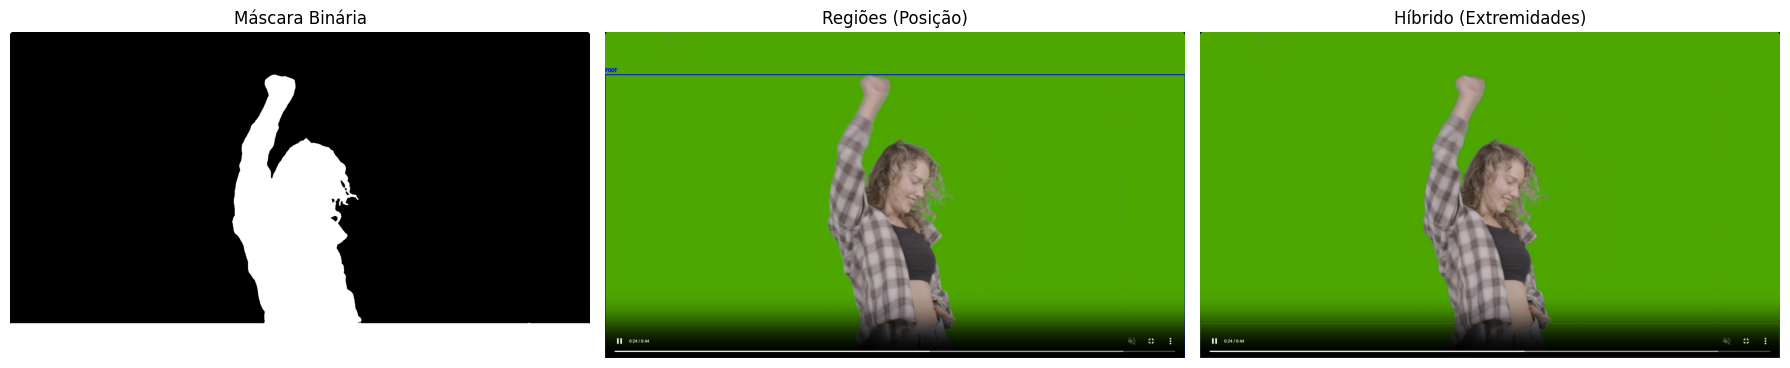

In [23]:
dados = detect_hybrid(mask_person)
visualize_hybrid_results(frame_test, mask_person, dados)

In [4]:
# Análise de Histograma
# Identificar cor dominante do fundo

def analyze_frame_colors(frame, n_clusters=5, show_analysis=True):
    """
    Analisa as cores predominantes no frame
    
    Retorna:
    - Cores dominantes (BGR)
    - Percentagem de cada cor
    - Histogramas HSV
    """
    
    # Redimensionar para acelerar (opcional)
    small_frame = cv.resize(frame, (frame.shape[1]//4, frame.shape[0]//4))
    
    # Converter para HSV
    hsv = cv.cvtColor(frame, cv.COLOR_BGR2HSV)
    
    # Calcular histogramas de cada canal
    h_hist = cv.calcHist([hsv], [0], None, [180], [0, 180])
    s_hist = cv.calcHist([hsv], [1], None, [256], [0, 256])
    v_hist = cv.calcHist([hsv], [2], None, [256], [0, 256])
    
    # Encontrar picos nos histogramas
    h_peaks = np.argsort(h_hist.flatten())[-3:]  # Top 3 Hues
    s_peaks = np.argsort(s_hist.flatten())[-3:]  # Top 3 Saturations
    
    # Análise de cor dominante usando regiões da imagem
    # Dividir frame em 9 regiões (3x3 grid)
    h, w = frame.shape[:2]
    regions = {
        'top_left': frame[0:h//3, 0:w//3],
        'top_center': frame[0:h//3, w//3:2*w//3],
        'top_right': frame[0:h//3, 2*w//3:w],
        'center_left': frame[h//3:2*h//3, 0:w//3],
        'center': frame[h//3:2*h//3, w//3:2*w//3],
        'center_right': frame[h//3:2*h//3, 2*w//3:w],
        'bottom_left': frame[2*h//3:h, 0:w//3],
        'bottom_center': frame[2*h//3:h, w//3:2*w//3],
        'bottom_right': frame[2*h//3:h, 2*w//3:w]
    }
    
    # Calcular cor média de cada região
    region_colors = {}
    for name, region in regions.items():
        mean_color = region.mean(axis=0).mean(axis=0)  # BGR
        region_colors[name] = mean_color
    
    # Identificar regiões de "fundo" (assumir que bordas = fundo)
    background_regions = ['top_left', 'top_center', 'top_right', 
                          'center_left', 'center_right',
                          'bottom_left', 'bottom_center', 'bottom_right']
    
    background_colors = [region_colors[r] for r in background_regions]
    dominant_bg_color = np.median(background_colors, axis=0)
    
    if show_analysis:
        fig = plt.figure(figsize=(16, 10))
        
        # Grid de layout
        gs = fig.add_gridspec(3, 4, hspace=0.3, wspace=0.3)
        
        # Frame original
        ax1 = fig.add_subplot(gs[0, :2])
        ax1.imshow(cv.cvtColor(frame, cv.COLOR_BGR2RGB))
        ax1.set_title("Frame Original", fontsize=14, fontweight='bold')
        ax1.axis('off')
        
        # Grid de regiões
        ax2 = fig.add_subplot(gs[0, 2:])
        grid_vis = frame.copy()
        cv.line(grid_vis, (w//3, 0), (w//3, h), (255, 255, 255), 2)
        cv.line(grid_vis, (2*w//3, 0), (2*w//3, h), (255, 255, 255), 2)
        cv.line(grid_vis, (0, h//3), (w, h//3), (255, 255, 255), 2)
        cv.line(grid_vis, (0, 2*h//3), (w, 2*h//3), (255, 255, 255), 2)
        ax2.imshow(cv.cvtColor(grid_vis, cv.COLOR_BGR2RGB))
        ax2.set_title("Divisão em Regiões", fontsize=14, fontweight='bold')
        ax2.axis('off')
        
        # Histograma H
        ax3 = fig.add_subplot(gs[1, 0])
        ax3.plot(h_hist, color='red', linewidth=2)
        ax3.set_title("Histograma Hue")
        ax3.set_xlabel("Hue (0-179)")
        ax3.set_xlim([0, 180])
        ax3.grid(True, alpha=0.3)
        # Marcar picos
        for peak in h_peaks:
            ax3.axvline(x=peak, color='green', linestyle='--', alpha=0.7)
        
        # Histograma S
        ax4 = fig.add_subplot(gs[1, 1])
        ax4.plot(s_hist, color='green', linewidth=2)
        ax4.set_title("Histograma Saturation")
        ax4.set_xlabel("Saturation (0-255)")
        ax4.set_xlim([0, 256])
        ax4.grid(True, alpha=0.3)
        
        # Histograma V
        ax5 = fig.add_subplot(gs[1, 2])
        ax5.plot(v_hist, color='blue', linewidth=2)
        ax5.set_title("Histograma Value")
        ax5.set_xlabel("Value (0-255)")
        ax5.set_xlim([0, 256])
        ax5.grid(True, alpha=0.3)
        
        # Cor dominante de fundo
        ax6 = fig.add_subplot(gs[1, 3])
        color_square = np.ones((100, 100, 3), dtype=np.uint8)
        color_square[:, :] = dominant_bg_color.astype(np.uint8)
        ax6.imshow(cv.cvtColor(color_square, cv.COLOR_BGR2RGB))
        ax6.set_title(f"Cor Dominante Fundo\nBGR: {dominant_bg_color.astype(int)}")
        ax6.axis('off')
        
        # Mapa de cores das regiões
        ax7 = fig.add_subplot(gs[2, :])
        region_vis = np.zeros((100, 900, 3), dtype=np.uint8)
        for i, (name, color) in enumerate(region_colors.items()):
            region_vis[:, i*100:(i+1)*100] = color.astype(np.uint8)
            
        ax7.imshow(cv.cvtColor(region_vis, cv.COLOR_BGR2RGB))
        ax7.set_title("Cores Médias de Cada Região")
        ax7.set_xticks(np.arange(50, 900, 100))
        ax7.set_xticklabels(list(region_colors.keys()), rotation=45, ha='right')
        ax7.set_yticks([])
        
        plt.show()
    
    return {
        'dominant_bg_color_bgr': dominant_bg_color,
        'h_peaks': h_peaks,
        's_peaks': s_peaks,
        'h_hist': h_hist,
        's_hist': s_hist,
        'v_hist': v_hist,
        'region_colors': region_colors
    }

In [22]:
# Segmentação Baseada em Histograma

def segment_by_background_color(frame, bg_color_bgr, tolerance=30, show_steps=True):
    """
    Segmenta removendo pixels similares à cor de fundo dominante
    
    Parâmetros:
    - bg_color_bgr: cor do fundo em BGR (numpy array)
    - tolerance: tolerância de diferença (0-255)
    """
    
    # Converter cor de fundo para HSV
    bg_color_hsv = cv.cvtColor(np.uint8([[bg_color_bgr]]), cv.COLOR_BGR2HSV)[0][0]
    
    # Converter frame para HSV
    hsv = cv.cvtColor(frame, cv.COLOR_BGR2HSV)
    
    # Criar ranges baseados na cor de fundo ± tolerância
    h_min = int(max(0, int(bg_color_hsv[0]) - tolerance//2))
    h_max = int(min(179, int(bg_color_hsv[0]) + tolerance//2))
    s_min = int(max(0, int(bg_color_hsv[1]) - tolerance))
    s_max = int(min(255, int(bg_color_hsv[1]) + tolerance))
    v_min = int(max(0, int(bg_color_hsv[2]) - tolerance))
    v_max = int(min(255, int(bg_color_hsv[2]) + tolerance))
    
    lower = np.array([h_min, s_min, v_min], dtype=np.uint8)
    upper = np.array([h_max, s_max, v_max], dtype=np.uint8)
    
    # Máscara do fundo
    mask_bg = cv.inRange(hsv, lower, upper)
    
    # Inverter (queremos pessoa)
    mask_person = cv.bitwise_not(mask_bg)
    
    # Limpeza morfológica
    kernel_size = (2,2)
    kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, kernel_size)
    mask_clean = cv.morphologyEx(mask_person, cv.MORPH_CLOSE, kernel, iterations=2)
    mask_clean = cv.morphologyEx(mask_clean, cv.MORPH_OPEN, kernel, iterations=1)
    
    if show_steps:
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        
        axes[0, 0].imshow(cv.cvtColor(frame, cv.COLOR_BGR2RGB))
        axes[0, 0].set_title("Original")
        axes[0, 0].axis('off')
        
        # Mostrar cor de fundo detectada
        bg_square = np.ones((100, 100, 3), dtype=np.uint8)
        bg_square[:, :] = bg_color_bgr.astype(np.uint8)
        axes[0, 1].imshow(cv.cvtColor(bg_square, cv.COLOR_BGR2RGB))
        axes[0, 1].set_title(f"Cor Fundo Detectada\nHSV: {bg_color_hsv}")
        axes[0, 1].axis('off')
        
        # Ranges usados
        info_text = f"Ranges HSV:\nH: [{h_min}, {h_max}]\nS: [{s_min}, {s_max}]\nV: [{v_min}, {v_max}]"
        axes[0, 2].text(0.1, 0.5, info_text, fontsize=12, family='monospace',
                       verticalalignment='center')
        axes[0, 2].set_title("Parâmetros")
        axes[0, 2].axis('off')
        
        axes[1, 0].imshow(mask_bg, cmap='gray')
        axes[1, 0].set_title("Máscara Fundo")
        axes[1, 0].axis('off')
        
        axes[1, 1].imshow(mask_person, cmap='gray')
        axes[1, 1].set_title("Máscara Invertida")
        axes[1, 1].axis('off')
        
        axes[1, 2].imshow(mask_clean, cmap='gray')
        axes[1, 2].set_title("Após Morfologia")
        axes[1, 2].axis('off')
        
        plt.tight_layout()
        plt.show()
    
    return mask_clean

In [6]:
# Segmentação por Detecção de Pele
# (Mantém tons de pele, remove resto)

def segment_by_skin_detection(frame, show_steps=True):
    """
    Abordagem inversa: detecta e mantém pixels de pele
    Remove tudo o que NÃO é pele
    """
    
    # Converter para YCrCb (melhor para detecção de pele)
    ycrcb = cv.cvtColor(frame, cv.COLOR_BGR2YCrCb)
    
    # Ranges de tons de pele em YCrCb (mais robusto que HSV)
    lower_skin = np.array([0, 133, 77], dtype=np.uint8)
    upper_skin = np.array([255, 173, 127], dtype=np.uint8)
    
    mask_skin_ycrcb = cv.inRange(ycrcb, lower_skin, upper_skin)
    
    # Também usar HSV como backup
    hsv = cv.cvtColor(frame, cv.COLOR_BGR2HSV)
    lower_skin_hsv = np.array([0, 20, 70], dtype=np.uint8)
    upper_skin_hsv = np.array([20, 255, 255], dtype=np.uint8)
    
    mask_skin_hsv = cv.inRange(hsv, lower_skin_hsv, upper_skin_hsv)
    
    # Combinar ambas as máscaras (OR lógico)
    mask_skin = cv.bitwise_or(mask_skin_ycrcb, mask_skin_hsv)
    
    # Limpeza morfológica agressiva
    kernel_size = (5,5)
    kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, kernel_size)
    mask_clean = cv.morphologyEx(mask_skin, cv.MORPH_CLOSE, kernel, iterations=3)
    mask_clean = cv.morphologyEx(mask_clean, cv.MORPH_OPEN, kernel, iterations=2)
    
    # Dilatar para capturar corpo completo (não só pele exposta)
    kernel_dilate = cv.getStructuringElement(cv.MORPH_ELLIPSE, (21, 21))
    mask_dilated = cv.dilate(mask_clean, kernel_dilate, iterations=3)
    
    if show_steps:
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        
        axes[0, 0].imshow(cv.cvtColor(frame, cv.COLOR_BGR2RGB))
        axes[0, 0].set_title("Original")
        axes[0, 0].axis('off')
        
        axes[0, 1].imshow(mask_skin_ycrcb, cmap='gray')
        axes[0, 1].set_title("Detecção Pele (YCrCb)")
        axes[0, 1].axis('off')
        
        axes[0, 2].imshow(mask_skin_hsv, cmap='gray')
        axes[0, 2].set_title("Detecção Pele (HSV)")
        axes[0, 2].axis('off')
        
        axes[1, 0].imshow(mask_skin, cmap='gray')
        axes[1, 0].set_title("Máscaras Combinadas")
        axes[1, 0].axis('off')
        
        axes[1, 1].imshow(mask_clean, cmap='gray')
        axes[1, 1].set_title("Após Morfologia")
        axes[1, 1].axis('off')
        
        axes[1, 2].imshow(mask_dilated, cmap='gray')
        axes[1, 2].set_title("Dilatada (corpo completo)")
        axes[1, 2].axis('off')
        
        plt.tight_layout()
        plt.show()
    
    return mask_dilated

In [7]:
# EXPERIÊNCIA 4: Método Híbrido Inteligente

def segment_hybrid_intelligent(frame, show_steps=True):
    """
    Combina análise de histograma + detecção de pele
    Mais robusto!
    """
    
    # Passo 1: Analisar cores do frame
    analysis = analyze_frame_colors(frame, show_analysis=False)
    bg_color = analysis['dominant_bg_color_bgr']
    
    # Passo 2: Segmentar por cor de fundo
    mask_bg_removal = segment_by_background_color(frame, bg_color, 
                                                   tolerance=50, show_steps=False)
    
    # Passo 3: Detectar pele
    mask_skin = segment_by_skin_detection(frame, show_steps=False)
    
    # Passo 4: Combinar (união)
    mask_combined = cv.bitwise_or(mask_bg_removal, mask_skin)
    
    # Passo 5: Limpeza final
    kernel_size = (5,5)
    kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, kernel_size)
    mask_final = cv.morphologyEx(mask_combined, cv.MORPH_CLOSE, kernel, iterations=2)
    
    if show_steps:
        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        
        axes[0, 0].imshow(cv.cvtColor(frame, cv.COLOR_BGR2RGB))
        axes[0, 0].set_title("Original")
        axes[0, 0].axis('off')
        
        # Cor de fundo detectada
        bg_square = np.ones((100, 100, 3), dtype=np.uint8)
        bg_square[:, :] = bg_color.astype(np.uint8)
        axes[0, 1].imshow(cv.cvtColor(bg_square, cv.COLOR_BGR2RGB))
        axes[0, 1].set_title("Fundo Auto-detectado")
        axes[0, 1].axis('off')
        
        axes[0, 2].imshow(mask_bg_removal, cmap='gray')
        axes[0, 2].set_title("Remoção de Fundo")
        axes[0, 2].axis('off')
        
        axes[1, 0].imshow(mask_skin, cmap='gray')
        axes[1, 0].set_title("Detecção de Pele")
        axes[1, 0].axis('off')
        
        axes[1, 1].imshow(mask_combined, cmap='gray')
        axes[1, 1].set_title("Máscaras Combinadas")
        axes[1, 1].axis('off')
        
        axes[1, 2].imshow(mask_final, cmap='gray')
        axes[1, 2].set_title("Resultado Final")
        axes[1, 2].axis('off')
        
        plt.tight_layout()
        plt.show()
    
    return mask_final

In [ ]:

# ==========================================
# EXPERIÊNCIA 1: Análise por Posição Vertical
# ==========================================

def detect_regions_by_position(mask, frame_shape, min_area=1000, show_analysis=True):
    """
    Detecta regiões ativas classificando por posição vertical
    
    Lógica:
    - Topo (0-30% altura): Cabeça ou mãos levantadas
    - Meio (30-70% altura): Mãos, braços
    - Baixo (70-100% altura): Pés, pernas
    
    Parâmetros:
    - mask: máscara binária da pessoa (255 = pessoa, 0 = fundo)
    - frame_shape: (height, width) do frame original
    - min_area: área mínima para considerar uma região
    """
    
    h, w = frame_shape[:2]
    
    # Encontrar todos os contornos
    contours, _ = cv.findContours(mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
    
    # Estruturas para guardar regiões
    hands = []
    feet = []
    head = None
    body_parts = []
    
    # Analisar cada contorno
    for cnt in contours:
        area = cv.contourArea(cnt)
        
        if area < min_area:
            continue
        
        # Calcular propriedades
        M = cv.moments(cnt)
        if M["m00"] == 0:
            continue
            
        cx = int(M["m10"] / M["m00"])  # Centro X
        cy = int(M["m01"] / M["m00"])  # Centro Y
        
        # Bounding box
        x, y, bw, bh = cv.boundingRect(cnt)
        
        # Aspect ratio (largura/altura)
        aspect_ratio = bw / float(bh) if bh > 0 else 0
        
        # Posição vertical relativa (0 = topo, 1 = fundo)
        relative_y = cy / h
        
        # Posição horizontal relativa (0 = esquerda, 1 = direita)
        relative_x = cx / w
        
        # Criar dicionário com info da região
        region_info = {
            'contour': cnt,
            'center': (cx, cy),
            'bbox': (x, y, bw, bh),
            'area': area,
            'relative_y': relative_y,
            'relative_x': relative_x,
            'aspect_ratio': aspect_ratio
        }
        
        body_parts.append(region_info)
        
        # Classificação por posição vertical
        if relative_y < 0.3:  # Topo
            if area > min_area * 5:  # Área grande = provavelmente cabeça
                if head is None or area > head['area']:
                    head = region_info
            else:
                hands.append(region_info)
                
        elif relative_y < 0.7:  # Meio
            hands.append(region_info)
            
        else:  # Baixo
            feet.append(region_info)
    
    if show_analysis:
        # Criar visualização
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        
        # 1. Máscara original com grid de zonas
        mask_rgb = cv.cvtColor(mask, cv.COLOR_GRAY2BGR)
        
        # Desenhar linhas de divisão
        y1 = int(h * 0.3)
        y2 = int(h * 0.7)
        cv.line(mask_rgb, (0, y1), (w, y1), (0, 255, 0), 2)
        cv.line(mask_rgb, (0, y2), (w, y2), (0, 255, 0), 2)
        
        # Labels das zonas
        cv.putText(mask_rgb, "TOPO (Cabeca/Maos)", (10, 30), 
                  cv.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        cv.putText(mask_rgb, "MEIO (Maos/Bracos)", (10, int(h*0.5)), 
                  cv.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        cv.putText(mask_rgb, "BAIXO (Pes/Pernas)", (10, int(h*0.85)), 
                  cv.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
        
        axes[0].imshow(cv.cvtColor(mask_rgb, cv.COLOR_BGR2RGB))
        axes[0].set_title("Zonas de Classificação")
        axes[0].axis('off')
        
        # 2. Contornos detectados
        contour_vis = cv.cvtColor(mask, cv.COLOR_GRAY2BGR)
        cv.drawContours(contour_vis, contours, -1, (0, 255, 0), 2)
        
        # Desenhar centros
        for part in body_parts:
            cv.circle(contour_vis, part['center'], 5, (255, 0, 0), -1)
        
        axes[1].imshow(cv.cvtColor(contour_vis, cv.COLOR_BGR2RGB))
        axes[1].set_title(f"Contornos Detectados ({len(body_parts)} regiões)")
        axes[1].axis('off')
        
        # 3. Classificação colorida
        classification_vis = np.zeros((h, w, 3), dtype=np.uint8)
        
        # Desenhar regiões classificadas
        if head:
            cv.drawContours(classification_vis, [head['contour']], -1, (255, 0, 255), -1)  # Magenta = Cabeça
            cv.putText(classification_vis, "HEAD", head['center'], 
                      cv.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)
        
        for hand in hands:
            cv.drawContours(classification_vis, [hand['contour']], -1, (0, 255, 0), -1)  # Verde = Mãos
            cv.putText(classification_vis, "HAND", hand['center'], 
                      cv.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)
        
        for foot in feet:
            cv.drawContours(classification_vis, [foot['contour']], -1, (255, 0, 0), -1)  # Azul = Pés
            cv.putText(classification_vis, "FOOT", foot['center'], 
                      cv.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)
        
        axes[2].imshow(cv.cvtColor(classification_vis, cv.COLOR_BGR2RGB))
        axes[2].set_title(f"Classificação\n(Cabeça:{1 if head else 0} | Mãos:{len(hands)} | Pés:{len(feet)})")
        axes[2].axis('off')
        
        plt.tight_layout()
        plt.show()
    
    return {
        'head': head,
        'hands': hands,
        'feet': feet,
        'all_parts': body_parts
    }

# ==========================================
# EXPERIÊNCIA 2: Análise por Extremidades
# Encontrar pontos extremos (dedos, pontas)
# ==========================================

def detect_extremities(mask, show_analysis=True):
    """
    Detecta pontos extremos da silhueta (dedos, mãos estendidas)
    Útil para interações precisas
    """
    
    # Encontrar maior contorno (assumir que é a pessoa completa)
    contours, _ = cv.findContours(mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
    
    if len(contours) == 0:
        return None
    
    # Pegar maior contorno
    main_contour = max(contours, key=cv.contourArea)
    
    # Encontrar convex hull
    hull = cv.convexHull(main_contour, returnPoints=True)
    
    # Encontrar defects (concavidades - podem ser entre dedos)
    hull_indices = cv.convexHull(main_contour, returnPoints=False)
    
    if len(hull_indices) > 3:
        defects = cv.convexityDefects(main_contour, hull_indices)
    else:
        defects = None
    
    # Encontrar pontos extremos
    leftmost = tuple(main_contour[main_contour[:, :, 0].argmin()][0])
    rightmost = tuple(main_contour[main_contour[:, :, 0].argmax()][0])
    topmost = tuple(main_contour[main_contour[:, :, 1].argmin()][0])
    bottommost = tuple(main_contour[main_contour[:, :, 1].argmax()][0])
    
    extremes = {
        'left': leftmost,
        'right': rightmost,
        'top': topmost,
        'bottom': bottommost
    }
    
    if show_analysis:
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        
        # 1. Contorno + Convex Hull
        vis1 = cv.cvtColor(mask, cv.COLOR_GRAY2BGR)
        cv.drawContours(vis1, [main_contour], -1, (0, 255, 0), 2)
        cv.drawContours(vis1, [hull], -1, (255, 0, 0), 2)
        
        axes[0].imshow(cv.cvtColor(vis1, cv.COLOR_BGR2RGB))
        axes[0].set_title("Contorno (verde) + Convex Hull (azul)")
        axes[0].axis('off')
        
        # 2. Pontos extremos
        vis2 = cv.cvtColor(mask, cv.COLOR_GRAY2BGR)
        cv.drawContours(vis2, [main_contour], -1, (255, 255, 255), 1)
        
        # Desenhar pontos extremos
        cv.circle(vis2, leftmost, 10, (255, 0, 0), -1)  # Azul = esquerda
        cv.circle(vis2, rightmost, 10, (0, 255, 0), -1)  # Verde = direita
        cv.circle(vis2, topmost, 10, (0, 255, 255), -1)  # Amarelo = topo
        cv.circle(vis2, bottommost, 10, (255, 0, 255), -1)  # Magenta = baixo
        
        cv.putText(vis2, "LEFT", (leftmost[0]-60, leftmost[1]), 
                  cv.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)
        cv.putText(vis2, "RIGHT", (rightmost[0]+10, rightmost[1]), 
                  cv.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)
        cv.putText(vis2, "TOP", (topmost[0], topmost[1]-20), 
                  cv.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)
        cv.putText(vis2, "BOTTOM", (bottommost[0], bottommost[1]+30), 
                  cv.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)
        
        axes[1].imshow(cv.cvtColor(vis2, cv.COLOR_BGR2RGB))
        axes[1].set_title("Pontos Extremos")
        axes[1].axis('off')
        
        # 3. Convexity Defects (concavidades)
        vis3 = cv.cvtColor(mask, cv.COLOR_GRAY2BGR)
        cv.drawContours(vis3, [main_contour], -1, (255, 255, 255), 1)
        
        if defects is not None:
            for i in range(defects.shape[0]):
                s, e, f, d = defects[i, 0]
                start = tuple(main_contour[s][0])
                end = tuple(main_contour[e][0])
                far = tuple(main_contour[f][0])
                
                # Desenhar apenas defects significativos
                if d > 5000:  # Threshold para profundidade
                    cv.circle(vis3, far, 5, (0, 0, 255), -1)
                    cv.line(vis3, start, far, (0, 255, 0), 1)
                    cv.line(vis3, end, far, (0, 255, 0), 1)
        
        axes[2].imshow(cv.cvtColor(vis3, cv.COLOR_BGR2RGB))
        axes[2].set_title("Convexity Defects\n(Concavidades - possíveis dedos)")
        axes[2].axis('off')
        
        plt.tight_layout()
        plt.show()
    
    return {
        'extremes': extremes,
        'main_contour': main_contour,
        'hull': hull,
        'defects': defects
    }

# ==========================================
# EXPERIÊNCIA 3: Método Híbrido
# Combina posição + forma + extremidades
# ==========================================

def detect_regions_hybrid(mask, frame_shape, min_area=1000, show_analysis=True):
    """
    Método mais robusto: combina análises
    """
    
    h, w = frame_shape[:2]
    
    # Análise por posição
    position_analysis = detect_regions_by_position(mask, frame_shape, 
                                                   min_area, show_analysis=False)
    
    # Análise de extremidades
    extremity_analysis = detect_extremities(mask, show_analysis=False)
    
    if extremity_analysis is None:
        return position_analysis
    
    # Refinar detecção de mãos usando extremidades
    extremes = extremity_analysis['extremes']
    
    # Verificar se pontos extremos laterais estão em posição de "mãos"
    left_point = extremes['left']
    right_point = extremes['right']
    
    # Considerar extremidades laterais como possíveis mãos se estiverem no meio
    hands_refined = position_analysis['hands'].copy()
    
    # Adicionar extremidades como "pontos de interesse" para colisão
    interest_points = []
    
    for name, point in extremes.items():
        relative_y = point[1] / h
        
        # Se extremidade está em zona de mão/braço
        if 0.2 < relative_y < 0.8:
            interest_points.append({
                'center': point,
                'type': f'extreme_{name}',
                'area': 100  # Área fictícia pequena
            })
    
    if show_analysis:
        fig, axes = plt.subplots(1, 2, figsize=(14, 7))
        
        # Visualização 1: Regiões por posição
        vis1 = cv.cvtColor(mask, cv.COLOR_GRAY2BGR)
        
        if position_analysis['head']:
            cv.drawContours(vis1, [position_analysis['head']['contour']], 
                          -1, (255, 0, 255), 2)
            cv.circle(vis1, position_analysis['head']['center'], 8, (255, 0, 255), -1)
        
        for hand in position_analysis['hands']:
            cv.drawContours(vis1, [hand['contour']], -1, (0, 255, 0), 2)
            cv.circle(vis1, hand['center'], 8, (0, 255, 0), -1)
        
        for foot in position_analysis['feet']:
            cv.drawContours(vis1, [foot['contour']], -1, (255, 0, 0), 2)
            cv.circle(vis1, foot['center'], 8, (255, 0, 0), -1)
        
        axes[0].imshow(cv.cvtColor(vis1, cv.COLOR_BGR2RGB))
        axes[0].set_title("Análise por Posição")
        axes[0].axis('off')
        
        # Visualização 2: Pontos de interesse (híbrido)
        vis2 = cv.cvtColor(mask, cv.COLOR_GRAY2BGR)
        
        # Desenhar todas as regiões
        for hand in hands_refined:
            cv.circle(vis2, hand['center'], 15, (0, 255, 0), 3)
            cv.putText(vis2, "HAND", hand['center'], 
                      cv.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 2)
        
        # Desenhar pontos extremos relevantes
        for point_info in interest_points:
            cv.circle(vis2, point_info['center'], 10, (255, 255, 0), -1)
            cv.putText(vis2, point_info['type'].split('_')[1].upper(), 
                      point_info['center'], 
                      cv.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 0), 1)
        
        axes[1].imshow(cv.cvtColor(vis2, cv.COLOR_BGR2RGB))
        axes[1].set_title(f"Pontos de Interação\n({len(hands_refined)} mãos + {len(interest_points)} extremidades)")
        axes[1].axis('off')
        
        plt.tight_layout()
        plt.show()
    
    return {
        'head': position_analysis['head'],
        'hands': hands_refined,
        'feet': position_analysis['feet'],
        'interest_points': interest_points,  # Pontos extremos para colisão
        'extremes': extremes
    }



🧪 EXPERIMENTAÇÃO DE SEGMENTAÇÃO
✅ Frame capturado

📊 EXPERIÊNCIA 1: Análise de Cores do Frame
------------------------------------------------------------


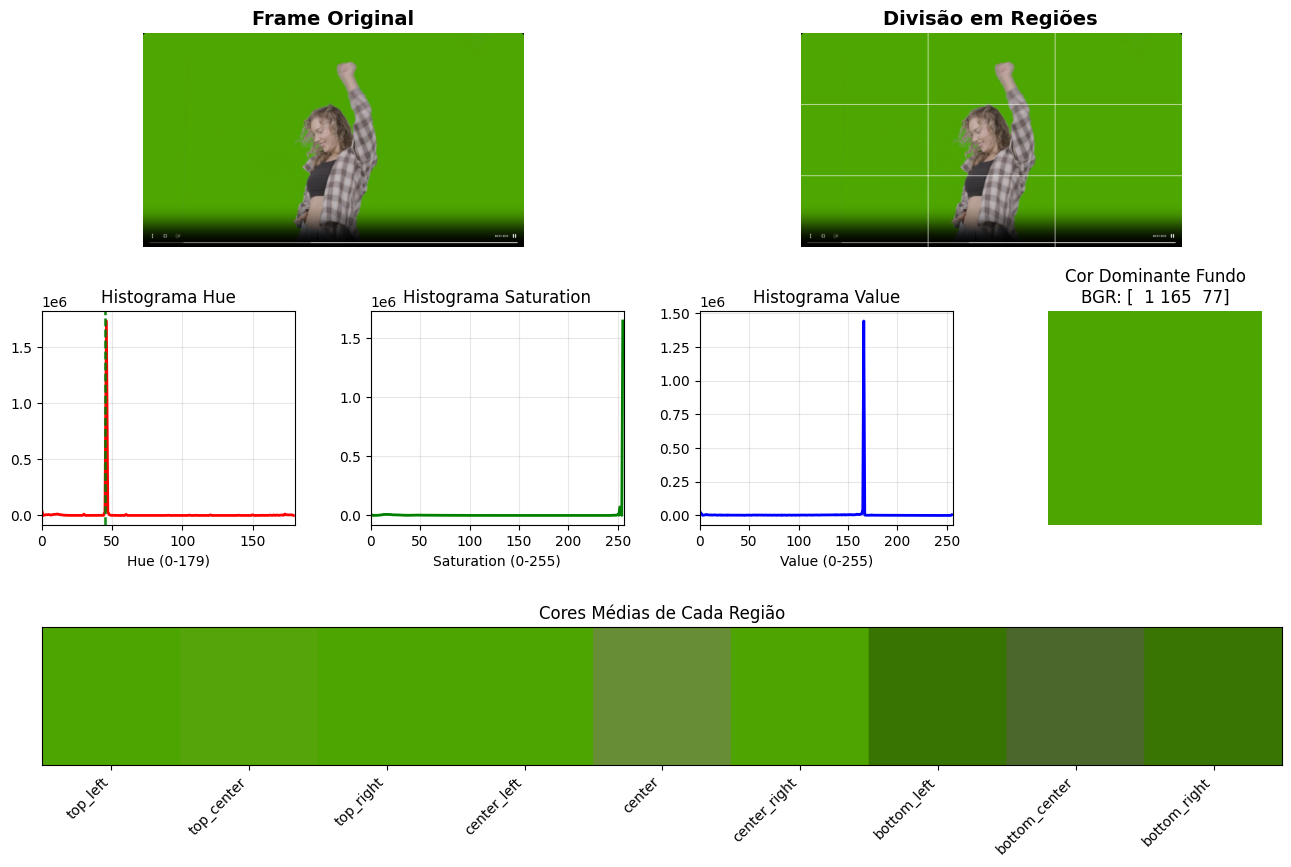


📊 EXPERIÊNCIA 2: Segmentação por Cor de Fundo Auto-detectada
------------------------------------------------------------


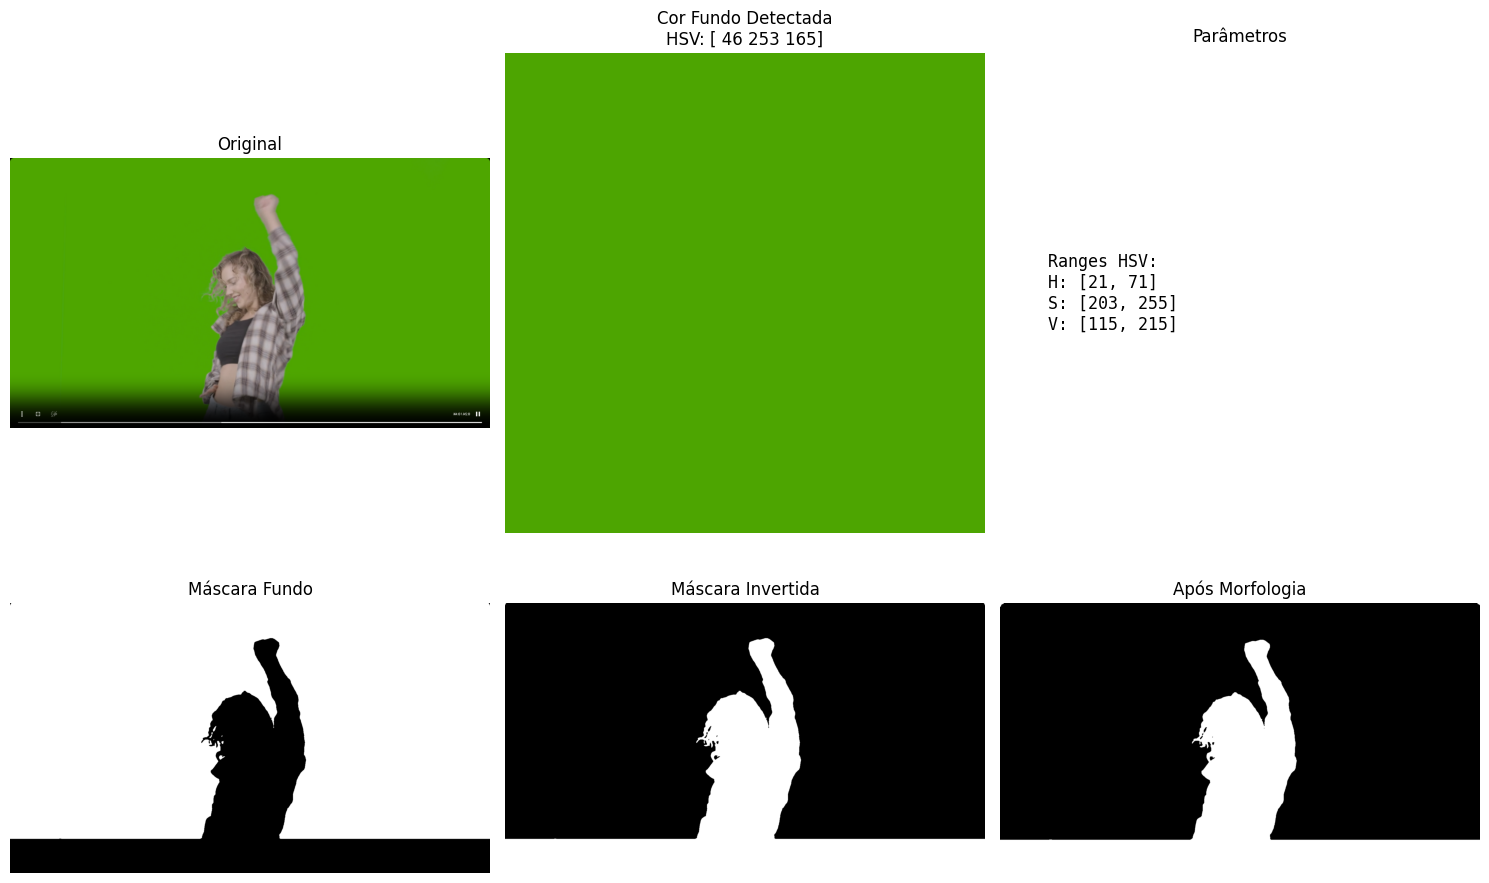


📊 EXPERIÊNCIA 3: Segmentação por Detecção de Pele
------------------------------------------------------------


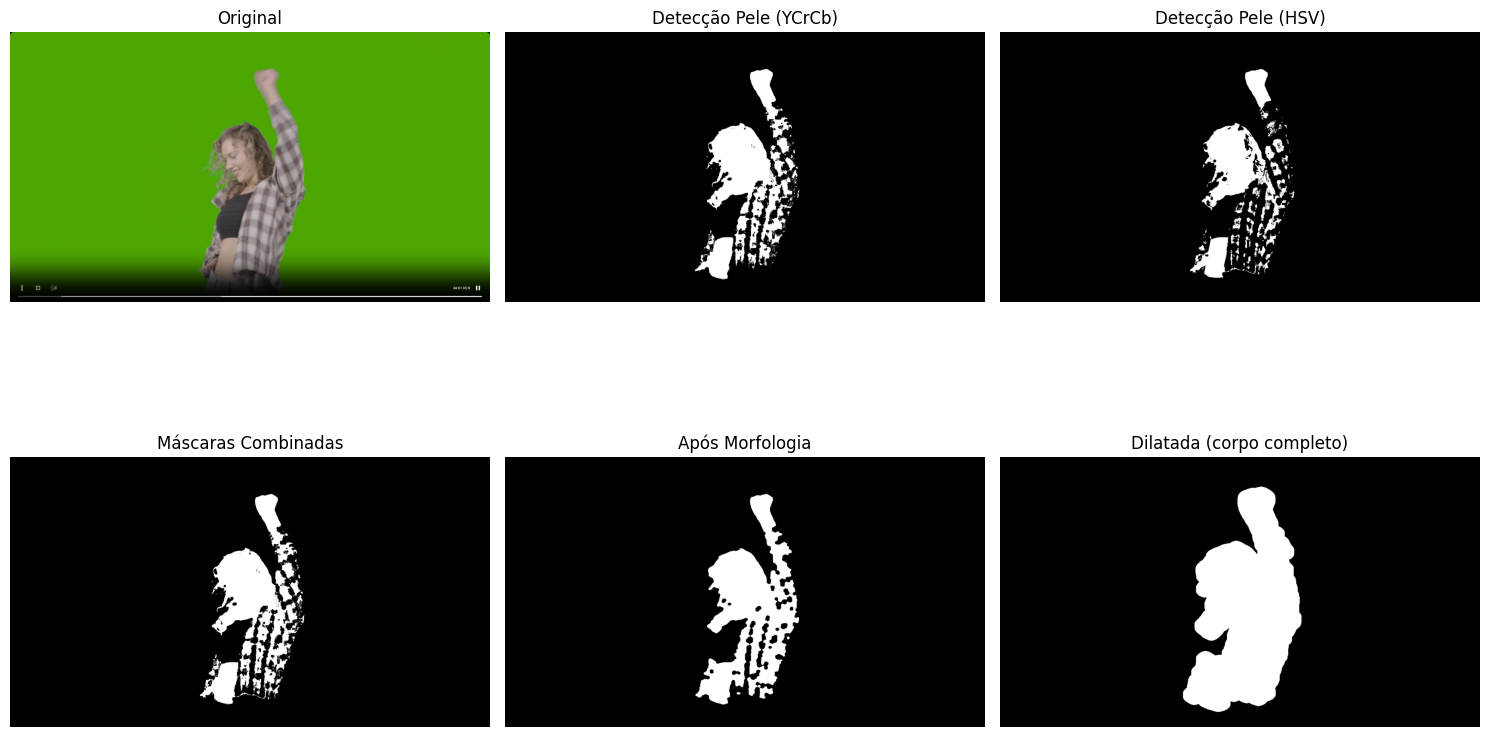


📊 EXPERIÊNCIA 4: Método Híbrido Inteligente
------------------------------------------------------------


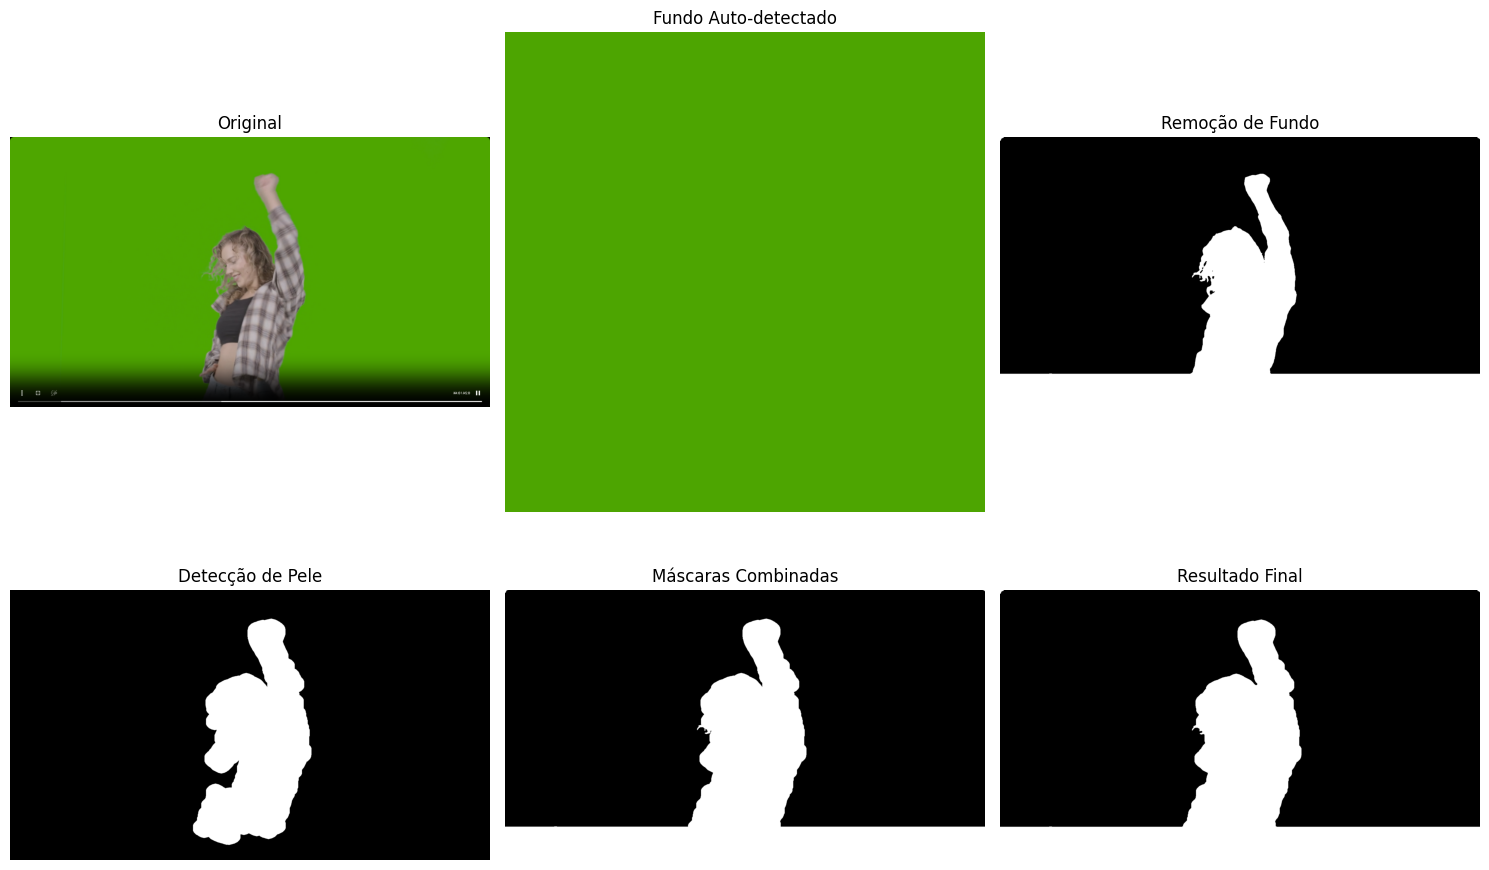


📈 ANÁLISE COMPARATIVA
Método 1 (Cor de Fundo): 22.3% detectado
Método 2 (Detecção Pele): 12.8% detectado
Método 3 (Híbrido):       24.6% detectado

💡 QUAL MÉTODO ESCOLHER?

Analisa os resultados acima e decide:

1. SE o método de COR DE FUNDO funcionou bem (pessoa bem segmentada):
   → Usar esse! É o mais simples e eficaz
   → Ajusta 'tolerance' se necessário (30-60)

2. SE o método de PELE funcionou melhor:
   → Indica que o fundo tem cores variadas
   → Bom para ambientes sem fundo uniforme

3. SE o HÍBRIDO deu melhor resultado:
   → Combina o melhor dos dois mundos
   → Mais robusto mas um pouco mais lento

PRÓXIMO PASSO: Testar em tempo real!



In [13]:
# TESTES PRÁTICOS


print("="*60)
print("🧪 EXPERIMENTAÇÃO DE SEGMENTAÇÃO")
print("="*60)

# Capturar frame
# cap = cv.VideoCapture(0)
# ret, frame_test = cap.read()
# cap.release()

folder = "assets/media/"
frame_test = cv.imread(folder + "img_teste_4.png")

if ret:
    frame_test = cv.flip(frame_test, 1)
    print("✅ Frame capturado\n")

print("📊 EXPERIÊNCIA 1: Análise de Cores do Frame")
print("-" * 60)
analysis = analyze_frame_colors(frame_test, show_analysis=True)

print("\n📊 EXPERIÊNCIA 2: Segmentação por Cor de Fundo Auto-detectada")
print("-" * 60)
mask_method1 = segment_by_background_color(frame_test, 
                                           analysis['dominant_bg_color_bgr'],
                                           tolerance=50, show_steps=True)

print("\n📊 EXPERIÊNCIA 3: Segmentação por Detecção de Pele")
print("-" * 60)
mask_method2 = segment_by_skin_detection(frame_test, show_steps=True)

print("\n📊 EXPERIÊNCIA 4: Método Híbrido Inteligente")
print("-" * 60)
mask_final = segment_hybrid_intelligent(frame_test, show_steps=True)

cap.release()

# Comparação estatística
print("\n" + "="*60)
print("📈 ANÁLISE COMPARATIVA")
print("="*60)

total_pixels = mask_method1.shape[0] * mask_method1.shape[1]

perc1 = (np.sum(mask_method1 > 0) / total_pixels) * 100
perc2 = (np.sum(mask_method2 > 0) / total_pixels) * 100
perc3 = (np.sum(mask_final > 0) / total_pixels) * 100

print(f"Método 1 (Cor de Fundo): {perc1:.1f}% detectado")
print(f"Método 2 (Detecção Pele): {perc2:.1f}% detectado")
print(f"Método 3 (Híbrido):       {perc3:.1f}% detectado")

print("\n" + "="*60)
print("💡 QUAL MÉTODO ESCOLHER?")
print("="*60)
print("""
Analisa os resultados acima e decide:

1. SE o método de COR DE FUNDO funcionou bem (pessoa bem segmentada):
   → Usar esse! É o mais simples e eficaz
   → Ajusta 'tolerance' se necessário (30-60)

2. SE o método de PELE funcionou melhor:
   → Indica que o fundo tem cores variadas
   → Bom para ambientes sem fundo uniforme

3. SE o HÍBRIDO deu melhor resultado:
   → Combina o melhor dos dois mundos
   → Mais robusto mas um pouco mais lento

PRÓXIMO PASSO: Testar em tempo real!
""")

🎯 DETECÇÃO DE REGIÕES ATIVAS

2️⃣ Aplicando segmentação (usa a TUA função aqui!)...


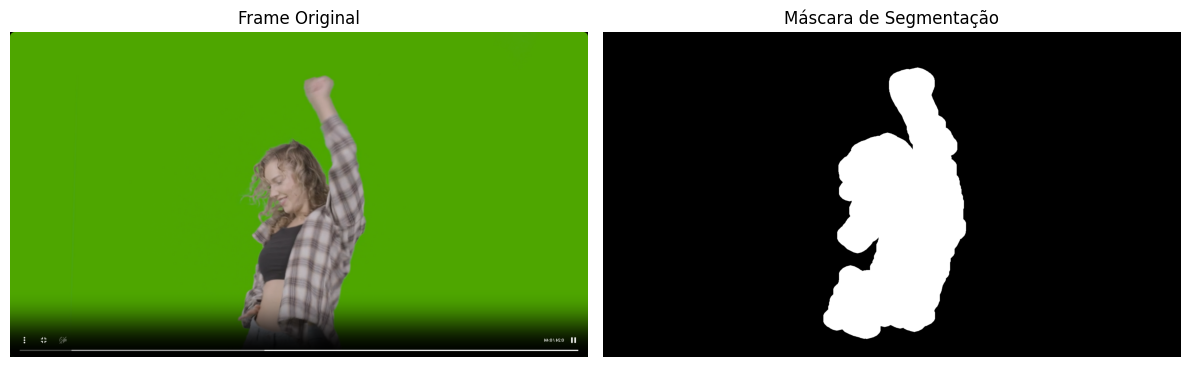


📊 EXPERIÊNCIA 1: Detecção por Posição Vertical
------------------------------------------------------------


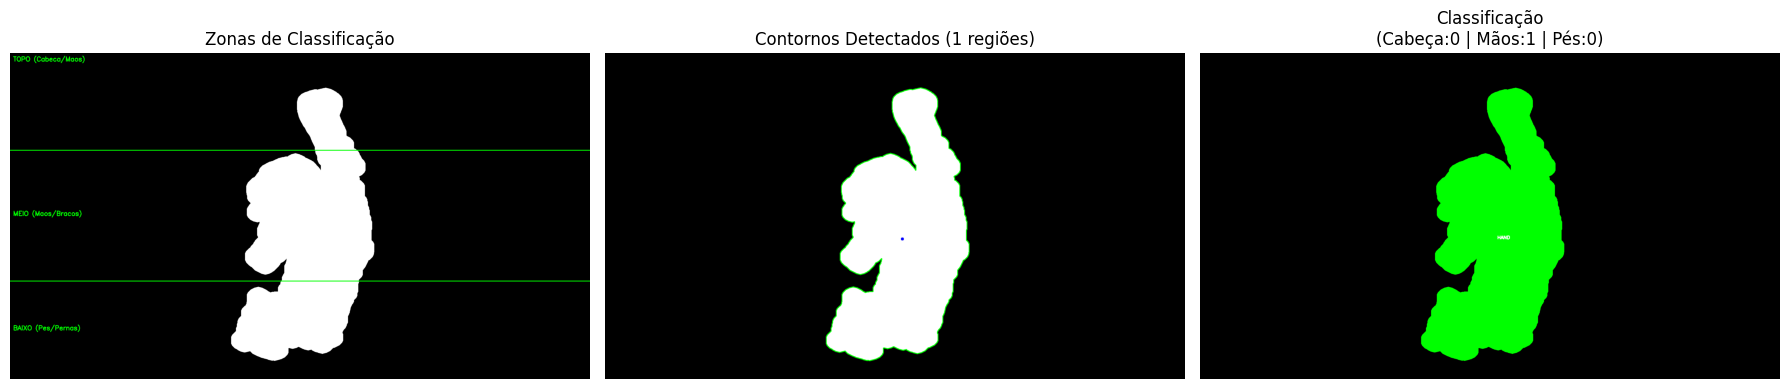


📊 EXPERIÊNCIA 2: Análise de Extremidades
------------------------------------------------------------


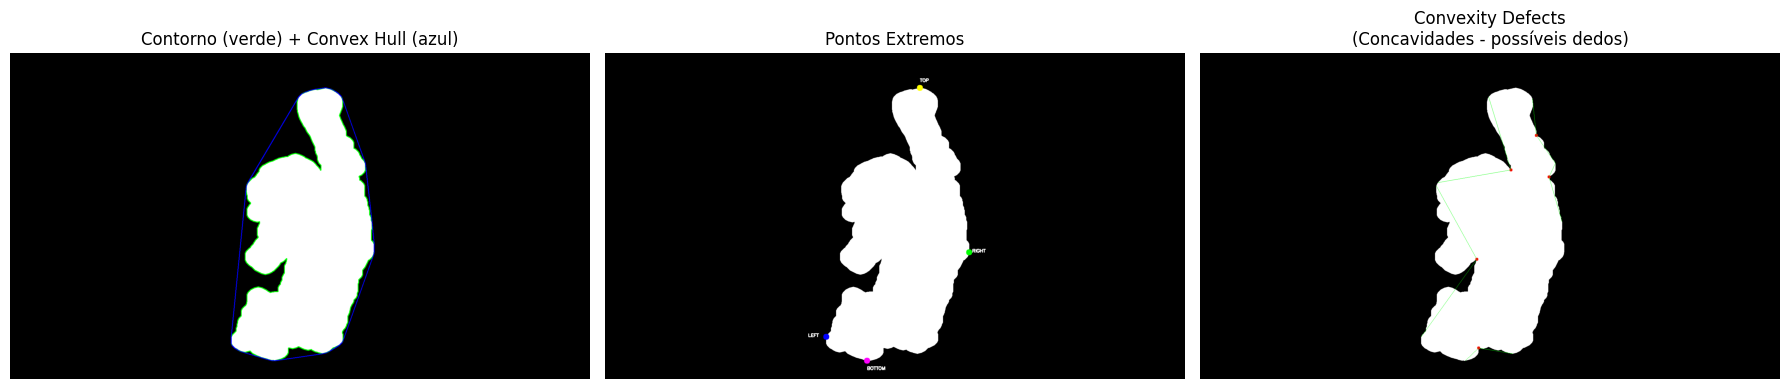


📊 EXPERIÊNCIA 3: Método Híbrido
------------------------------------------------------------


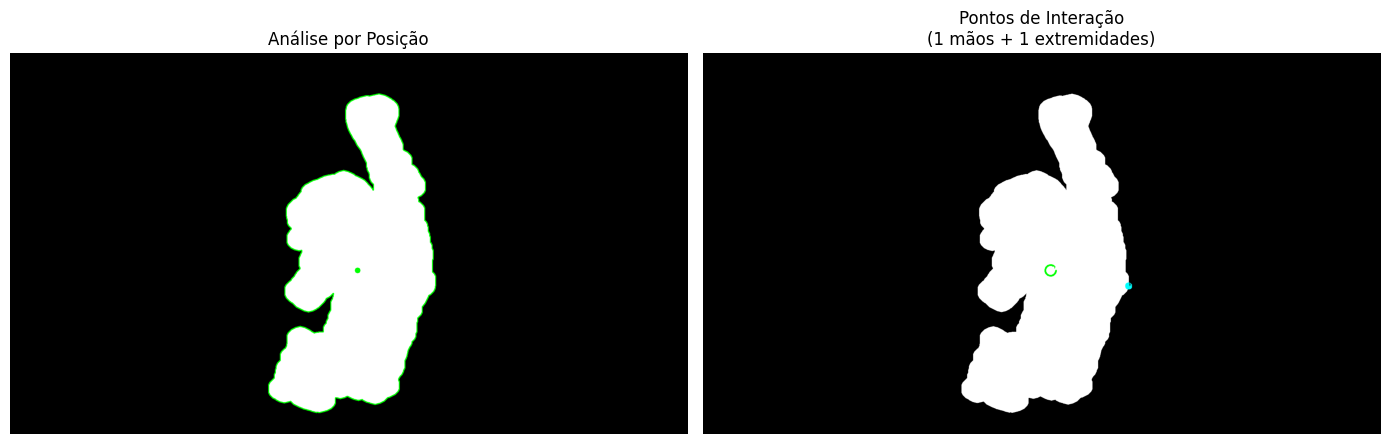


📊 RESUMO DOS RESULTADOS
Método 1 (Posição): 1 mãos, 0 pés
Método 3 (Híbrido): 1 mãos, 1 pontos de interesse

💡 RECOMENDAÇÃO:
- Para SIMPLICIDADE: Usa Método 1 (posição vertical)
- Para PRECISÃO: Usa Método 3 (híbrido - inclui extremidades)

✅ Próxima fase: Sistema de Objetos Virtuais + Colisões!


In [16]:
# ==========================================
# TESTE PRÁTICO
# ==========================================

print("="*60)
print("🎯 DETECÇÃO DE REGIÕES ATIVAS")
print("="*60)


# IMPORTANTE: Aqui precisas da TUA função de segmentação
# Substitui isto pela função que desenvolveste antes!
print("\n2️⃣ Aplicando segmentação (usa a TUA função aqui!)...")


# Mostrar máscara
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(frame_test, cv.COLOR_BGR2RGB))
plt.title("Frame Original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(mask_method2, cmap='gray')
plt.title("Máscara de Segmentação")
plt.axis('off')
plt.tight_layout()
plt.show()

print("\n📊 EXPERIÊNCIA 1: Detecção por Posição Vertical")
print("-" * 60)
regions_position = detect_regions_by_position(mask_method2, frame_test.shape, 
                                              min_area=1000, show_analysis=True)

print("\n📊 EXPERIÊNCIA 2: Análise de Extremidades")
print("-" * 60)
extremities = detect_extremities(mask_method2, show_analysis=True)

print("\n📊 EXPERIÊNCIA 3: Método Híbrido")
print("-" * 60)
regions_hybrid = detect_regions_hybrid(mask_method2, frame_test.shape, 
                                       min_area=1000, show_analysis=True)

print("\n" + "="*60)
print("📊 RESUMO DOS RESULTADOS")
print("="*60)
print(f"Método 1 (Posição): {len(regions_position['hands'])} mãos, {len(regions_position['feet'])} pés")
print(f"Método 3 (Híbrido): {len(regions_hybrid['hands'])} mãos, {len(regions_hybrid['interest_points'])} pontos de interesse")

print("\n💡 RECOMENDAÇÃO:")
print("- Para SIMPLICIDADE: Usa Método 1 (posição vertical)")
print("- Para PRECISÃO: Usa Método 3 (híbrido - inclui extremidades)")
print("\n✅ Próxima fase: Sistema de Objetos Virtuais + Colisões!")

In [33]:
# ==========================================
# TESTE EM TEMPO REAL (WEBCAM OU VÍDEO)
# ==========================================

def test_realtime_video(video_path=None, color_ranges=None, show_mask=True, show_regions=True):
    """
    Teste em tempo real com webcam ou ficheiro de vídeo.
    
    Parâmetros:
    - video_path: Caminho para ficheiro de vídeo (str). Se None, usa Webcam (0).
    - color_ranges: Dicionário com ranges HSV. Se None, usa default da função de segmentação.
    - show_mask: Booleano para mostrar janela da máscara.
    - show_regions: Booleano para desenhar bounding boxes e centros.
    """
    
    # Determinar a fonte: Webcam (0) ou ficheiro
    source = 0 if video_path is None else video_path
    source_name = "Webcam" if video_path is None else f"Video: {video_path}"
    
    cap = cv.VideoCapture(source)
    
    if not cap.isOpened():
        print(f"❌ Erro: Não foi possível abrir a fonte: {source}")
        return
    
    # Configurações iniciais
    display_mask = show_mask
    display_regions = show_regions
    paused = False
    
    # Estatísticas
    frame_count = 0
    fps_list = []
    
    print("="*60)
    print(f"🎥 A INICIAR TESTE: {source_name}")
    print("="*60)
    print("Controlos:")
    print("  q - Sair")
    print("  m - Ligar/Desligar Máscara")
    print("  r - Ligar/Desligar Regiões")
    print("  s - Salvar frame atual")
    print("  SPACE - Pausar/Continuar")
    print("="*60)
    
    while True:
        if not paused:
            ret, frame = cap.read()
            
            # Lógica de fim de vídeo / erro
            if not ret:
                if video_path is not None:
                    # Se for vídeo, faz loop (volta ao início)
                    print("🔄 Fim do vídeo, a reiniciar...")
                    cap.set(cv.CAP_PROP_POS_FRAMES, 0)
                    continue
                else:
                    print("❌ Falha ao capturar frame da webcam.")
                    break
            
            # Espelhar apenas se for webcam (vídeos gravados não devem ser espelhados)
            if video_path is None:
                frame = cv.flip(frame, 1)
            
            # Redimensionar se o vídeo for gigante (opcional, para performance)
            if frame.shape[1] > 1280:
                scale = 1280 / frame.shape[1]
                frame = cv.resize(frame, None, fx=scale, fy=scale)

            h, w = frame.shape[:2]
            
            # --- INÍCIO PROCESSAMENTO ---
            start_time = time.time()
            
            # 1. SEGMENTAÇÃO
            analysis = analyze_frame_colors(frame, show_analysis=False)

            mask = segment_by_background_color(frame, 
                                                    analysis['dominant_bg_color_bgr'],
                                                    tolerance=50, show_steps=False)
            
            # 2. DETECÇÃO DE REGIÕES
            # Ajustar min_area proporcionalmente ao tamanho do vídeo pode ser útil
            min_area_dynamic = (w * h) * 0.001 # Ex: 0.1% da imagem

            regions = detect_regions_by_position(mask, frame.shape, min_area=max(500, min_area_dynamic), show_analysis=False)
#            regions = detect_regions_hybrid(mask, frame.shape, min_area=max(500, min_area_dynamic), show_analysis=False)

            
            # Calcular FPS
            process_time = time.time() - start_time
            fps = 1.0 / process_time if process_time > 0 else 0
            
            fps_list.append(fps)
            if len(fps_list) > 30: fps_list.pop(0)
            avg_fps = np.mean(fps_list)
            
            frame_count += 1
            # --- FIM PROCESSAMENTO ---

        # ==========================================
        # VISUALIZAÇÃO
        # ==========================================
        display_frame = frame.copy()
        
        if display_regions:
            # Desenhar Cabeça
            if regions['head']:
                r = regions['head']
                cv.rectangle(display_frame, r['bbox'], (255, 0, 255), 2)
                cv.putText(display_frame, "HEAD", (r['bbox'][0], r['bbox'][1]-10), 
                           cv.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 255), 2)
                cv.circle(display_frame, r['center'], 5, (255, 0, 255), -1)

            # Desenhar Mãos
            for i, r in enumerate(regions['hands']):
                cv.rectangle(display_frame, r['bbox'], (0, 255, 0), 2)
                cv.putText(display_frame, f"HAND {i+1}", (r['bbox'][0], r['bbox'][1]-10), 
                           cv.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)
                cv.circle(display_frame, r['center'], 5, (0, 255, 0), -1)

            # Desenhar Pés
            for i, r in enumerate(regions['feet']):
                cv.rectangle(display_frame, r['bbox'], (255, 0, 0), 2)
                cv.putText(display_frame, f"FOOT {i+1}", (r['bbox'][0], r['bbox'][1]-10), 
                           cv.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 2)
                cv.circle(display_frame, r['center'], 5, (255, 0, 0), -1)

        # Informações na tela (HUD)
        cv.rectangle(display_frame, (5, 5), (250, 110), (0, 0, 0), -1) # Fundo preto para texto
        cv.putText(display_frame, f"FPS: {avg_fps:.1f}", (15, 30), cv.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)
        cv.putText(display_frame, f"Frame: {frame_count}", (15, 60), cv.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 1)
        cv.putText(display_frame, f"Maos: {len(regions['hands'])} | Pes: {len(regions['feet'])}", 
                   (15, 90), cv.FONT_HERSHEY_SIMPLEX, 0.6, (200, 200, 200), 1)

        if paused:
            cv.putText(display_frame, "PAUSADO", (w//2 - 100, h//2), cv.FONT_HERSHEY_SIMPLEX, 1.5, (0, 0, 255), 3)

        cv.imshow('Analise de Movimento', display_frame)
        
        if display_mask:
            # Mostrar máscara em janela separada (recolorida para ver melhor)
            mask_display = cv.cvtColor(mask, cv.COLOR_GRAY2BGR)
            cv.putText(mask_display, "MASCARA (BINARIA)", (10, 30), cv.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
            cv.imshow('Mask Debug', mask_display)
        else:
            # Se o utilizador desligar a máscara, fecha a janela para não ocupar espaço
            try: cv.destroyWindow('Mask Debug')
            except: pass

        # ==========================================
        # INPUT DO UTILIZADOR
        # ==========================================
        key = cv.waitKey(1 if not paused else 30) & 0xFF
        
        if key == ord('q'):
            break
        elif key == ord('m'):
            display_mask = not display_mask
            print(f"Visualização Máscara: {display_mask}")
        elif key == ord('r'):
            display_regions = not display_regions
            print(f"Visualização Regiões: {display_regions}")
        elif key == ord(' '):
            paused = not paused
        elif key == ord('s'):
            filename = f"capture_{int(time.time())}.png"
            cv.imwrite(filename, display_frame)
            print(f"📸 Frame salvo: {filename}")

    cap.release()
    cv.destroyAllWindows()
    print("Teste finalizado.")

# ==========================================
# COMO EXECUTAR
# ==========================================

# 1. Para usar WEBCAM (padrão):
#test_realtime_video()

# 2. Para usar UM VÍDEO (exemplo):
test_realtime_video(video_path="assets/media/mixkit-video_teste1.mp4")

🎥 A INICIAR TESTE: Video: assets/media/mixkit-video_teste1.mp4
Controlos:
  q - Sair
  m - Ligar/Desligar Máscara
  r - Ligar/Desligar Regiões
  s - Salvar frame atual
  SPACE - Pausar/Continuar
🔄 Fim do vídeo, a reiniciar...
🔄 Fim do vídeo, a reiniciar...
🔄 Fim do vídeo, a reiniciar...
🔄 Fim do vídeo, a reiniciar...
🔄 Fim do vídeo, a reiniciar...
Teste finalizado.


In [40]:
def detect_extremities_realtime(mask, min_area=2000):
    """
    Versão adaptada para vídeo: processa e retorna dados, não usa Matplotlib.
    """
    # Encontrar contornos
    contours, _ = cv.findContours(mask, cv.RETR_EXTERNAL, cv.CHAIN_APPROX_SIMPLE)
    
    if len(contours) == 0:
        return None
    
    # Pegar maior contorno
    main_contour = max(contours, key=cv.contourArea)
    
    if cv.contourArea(main_contour) < min_area:
        return None
    
    # 1. Convex Hull para DESENHO (pontos)
    hull_points = cv.convexHull(main_contour, returnPoints=True)
    
    # 2. Convex Hull para DEFECTS (índices)
    hull_indices = cv.convexHull(main_contour, returnPoints=False)
    
    # 3. Calcular Defects (concavidades)
    defects = None
    if len(hull_indices) > 3:
        try:
            defects = cv.convexityDefects(main_contour, hull_indices)
        except:
            defects = None
    
    # 4. Encontrar pontos extremos
    # Nota: c[0] é o ponto (x, y)
    leftmost = tuple(main_contour[main_contour[:, :, 0].argmin()][0])
    rightmost = tuple(main_contour[main_contour[:, :, 0].argmax()][0])
    topmost = tuple(main_contour[main_contour[:, :, 1].argmin()][0])
    bottommost = tuple(main_contour[main_contour[:, :, 1].argmax()][0])
    
    return {
        'contour': main_contour,
        'hull': hull_points,
        'defects': defects,
        'extremes': {
            'left': leftmost,
            'right': rightmost,
            'top': topmost,
            'bottom': bottommost
        }
    }

In [35]:
def draw_extremities_on_frame(frame, data):
    """
    Recebe os dados calculados e desenha no frame usando OpenCV.
    """
    if data is None:
        return frame

    cnt = data['contour']
    hull = data['hull']
    defects = data['defects']
    extr = data['extremes']
    
    # 1. Desenhar o Contorno (Verde) e o Hull (Azul)
    cv.drawContours(frame, [cnt], -1, (0, 255, 0), 2)
    cv.drawContours(frame, [hull], -1, (255, 0, 0), 2)
    
    # 2. Desenhar Pontos Extremos (Círculos coloridos)
    # Esquerda (Azul), Direita (Verde), Topo (Amarelo), Baixo (Magenta)
    cv.circle(frame, extr['left'], 8, (255, 0, 0), -1)
    cv.circle(frame, extr['right'], 8, (0, 255, 0), -1)
    cv.circle(frame, extr['top'], 8, (0, 255, 255), -1)
    cv.circle(frame, extr['bottom'], 8, (255, 0, 255), -1)
    
    # Legendas dos extremos
    cv.putText(frame, "Esq", (extr['left'][0]-40, extr['left'][1]), cv.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
    cv.putText(frame, "Dir", (extr['right'][0]+10, extr['right'][1]), cv.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
    cv.putText(frame, "Topo", (extr['top'][0], extr['top'][1]-10), cv.FONT_HERSHEY_SIMPLEX, 0.5, (255, 255, 255), 1)
    
    # 3. Desenhar Defects (Concavidades / Entre os dedos)
    if defects is not None:
        for i in range(defects.shape[0]):
            s, e, f, d = defects[i, 0]
            
            # Filtro de profundidade (para ignorar pequenos ruídos)
            # Ajustar este valor conforme a distância da câmara (ex: 5000 a 10000)
            if d > 8000: 
                start = tuple(cnt[s][0])
                end = tuple(cnt[e][0])
                far = tuple(cnt[f][0])
                
                # Desenhar linha do triângulo do defect
                cv.line(frame, start, far, (0, 255, 255), 1)
                cv.line(frame, end, far, (0, 255, 255), 1)
                
                # Desenhar círculo no ponto mais profundo (concavidade)
                cv.circle(frame, far, 5, (0, 0, 255), -1)
                
    return frame

In [41]:
def test_realtime_extremities(video_path=None, color_ranges=None):
    
    source = 0 if video_path is None else video_path
    cap = cv.VideoCapture(source)
    
    if not cap.isOpened():
        print("Erro ao abrir vídeo")
        return

    print("Q para sair | M para ver a máscara")
    show_mask = False

    while True:
        ret, frame = cap.read()
        if not ret:
            if video_path: cap.set(cv.CAP_PROP_POS_FRAMES, 0); continue
            else: break
        
        # Espelhar se for webcam
        if video_path is None:
            frame = cv.flip(frame, 1)
            
        # 1. SEGMENTAÇÃO (Usa a tua função anterior)
                    # 1. SEGMENTAÇÃO
        analysis = analyze_frame_colors(frame, show_analysis=False)

        mask = segment_by_background_color(frame, 
                                                analysis['dominant_bg_color_bgr'],
                                                tolerance=50, show_steps=False)
    
        # 2. DETECÇÃO (Nova função)
        data = detect_extremities_realtime(mask)
        
        # 3. VISUALIZAÇÃO
        display_frame = frame.copy()
        
        if data is not None:
            # Desenha tudo usando a função auxiliar
            draw_extremities_on_frame(display_frame, data)
            
            # Exemplo: Usar o ponto mais alto para controlar algo
            top_point = data['extremes']['top']
            cv.putText(display_frame, f"Topo Y: {top_point[1]}", (10, 30), 
                       cv.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 255), 2)

        cv.imshow('Detecao de Extremidades', display_frame)
        
        if show_mask:
            cv.imshow('Mascara', mask)

        key = cv.waitKey(1) & 0xFF
        if key == ord('q'): break
        if key == ord('m'): show_mask = not show_mask

    cap.release()
    cv.destroyAllWindows()

In [44]:
# 1. Para usar WEBCAM (padrão):
#test_realtime_video()

# 2. Para usar UM VÍDEO (exemplo):
test_realtime_extremities(video_path="assets/media/video_teste1.mp4")

Q para sair | M para ver a máscara


### <center>**Conclusão**</center> <a class="anchor" id="chapter11"></a>
